<div style="padding:22px 26px; border-radius:14px; background:linear-gradient(135deg,#7A0019,#9E1B32); color:white; margin-bottom:18px;">
  <div style="font-size:30px; font-weight:700; line-height:1.2;">Robust Computer Port Detection with YOLOv8</div>
  <div style="font-size:16px; margin-top:7px; opacity:0.95;">CS4343 · Deep Learning · Final Project</div>
</div>

**Team:** Yutaro Matsuyama, Dajiro Tanimura, Markenson Adam, Regan John, Ruiz Jeronimo

We fine-tune a COCO-pretrained **YOLOv8s** detector to find and label six computer ports
(DisplayPort, Ethernet, HDMI, USB-A, USB-C, VGA) in device photos.

- **RQ1.** How accurately can the model detect each port type, and which types are most often missed or confused?
- **RQ2.** How much does accuracy drop under Gaussian noise, motion blur, JPEG compression, and low brightness,
  and does training-time augmentation make the model more robust?

### Notebook Overview

| Section | Content | Research question |
|:--|:--|:--|
| 1 | Dataset statistics and examples | — |
| 2 | Model, loss, and training setup | — |
| 3 | Train the baseline (with augmentation) | RQ1 |
| 4 | Augmentation ablation (no augmentation) | RQ2 |
| 5 | Test-set evaluation per class | RQ1 |
| 6 | Robustness to image corruptions | RQ2 |
| 7 | Failure cases | RQ1 |
| 8 | Summary | RQ1, RQ2 |

The training, evaluation, and corruption code lives in `train.py`, `evaluate.py`, and `robustness.py`.
This notebook calls those functions and shows the results.

## Setup and Imports

The notebook runs in **Google Colab with a T4 GPU** (recommended) or in a **local Jupyter** environment.
It detects which one automatically.

### Running in Google Colab (T4 GPU)

**1. Upload the project to Google Drive.** Create the folder `MyDrive/CS4343-port-detection` and upload:

```
CS4343-port-detection/
├── CS4343_Project_Port_Detection.ipynb
├── config.py   train.py   evaluate.py   robustness.py
├── data.yaml   requirements.txt   pytest.ini   README.md
├── tests/
└── prepared/        (~120 MB; download link in README.md)
```

- Do **not** upload `runs/`, `corrupted/`, `yolov8s.pt`, `__pycache__/`, or `example/`. They are recreated automatically.
- The folder name must match exactly. If you use another name or location, change `DRIVE_DIR` in the settings cell.
- If a teammate shared the folder with you, right-click it → **Organize → Add shortcut** and place the shortcut in My Drive.

**2. Open the notebook in Colab.** In Drive, right-click the notebook → **Open with → Google Colaboratory**
(if it is not listed, choose **Connect more apps** and add Colaboratory).
Then select **Runtime → Change runtime type → T4 GPU → Save**.

**3. Run all cells.** Make sure `QUICK_TEST = False` in the settings cell, then choose **Runtime → Run all**
(`Ctrl+F9`, or `⌘+F9` on a Mac). A pop-up asks for access to Google Drive. Allow it; the notebook waits until you do.

| Step | Expected time on a T4 |
|:--|:--|
| Copy code and images from Drive to Colab | 1–3 min |
| Baseline training (Section 3) | ~1 h |
| No-augmentation training (Section 4) | 30–60 min |
| Test evaluation and robustness (Sections 5–6) | ~20 min |

**4. Find the results.** Everything written to `runs/` is saved directly to `MyDrive/CS4343-port-detection/runs/`:

- `baseline/weights/best.pt`: trained weights
- `eval_baseline_test/`: confusion matrix, PR curves, `per_class.csv`
- `robust_baseline/robustness.csv`: robustness table

After the run, choose **File → Save** to keep the notebook with all its plots in Drive.

**Limits of free Colab**

- Keep the browser tab open and the computer awake. Idle sessions are disconnected.
- If Colab says no GPU is available (usage limit), wait a few hours or run the notebook from a teammate's account.
- If the session disconnects during training, follow the resume instructions in Section 3.

### Running in local Jupyter

Open the notebook from the project folder. Full training needs a CUDA GPU, or probably an Apple Silicon Mac
with at least 16 GB of memory (an 8 GB M1 runs out of memory). On a laptop, set `QUICK_TEST = True` to check that
every cell runs in about 4 minutes (1 epoch on 5% of the data; the numbers are meaningless).
Quick-test outputs are saved separately in `runs/quick_*`.

In [3]:
# ---- Settings ----
QUICK_TEST = False   # True: 1 epoch on 5% of the data at 320 px, only to check that everything runs
RUN_IMG960 = False   # optional resolution ablation (about 2x slower than 640 px)
DRIVE_DIR = "/content/drive/MyDrive/CS4343-port-detection"  # Colab only: project folder on Google Drive

In [4]:
import os
import shutil
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/project")
    # Copy code and images to the local disk (reading images from Drive is slow).
    shutil.copytree(DRIVE_DIR, PROJECT, dirs_exist_ok=True,
                    ignore=shutil.ignore_patterns("runs", "corrupted", "example", "*.pt", "__pycache__"))
    # Keep runs/ on Drive so weights and results survive a disconnect.
    drive_runs = Path(DRIVE_DIR) / "runs"
    drive_runs.mkdir(exist_ok=True)
    if not (PROJECT / "runs").exists():
        (PROJECT / "runs").symlink_to(drive_runs)
else:
    PROJECT = Path.cwd()  # the notebook sits in the project folder

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))
assert (PROJECT / "train.py").exists(), f"train.py not found in {PROJECT}"
assert (PROJECT / "prepared" / "images" / "train").exists(), "Download prepared/ first (see README)"
print("Running in:", "Colab" if IN_COLAB else "local Jupyter", "|", PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in: Colab | /content/project


In [5]:
# Install Ultralytics (PyTorch is already installed in Colab).
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.8 MB/s eta 0:00:00


In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from config import CLASSES, DATASET, RUNS, pick_device
from evaluate import evaluate
from robustness import SEVERITY, corrupt, run as run_robustness
from train import AUGMENT, train

SEED = 42
DEVICE = pick_device()
print("Selected device:", DEVICE)
if DEVICE != "0" and not QUICK_TEST:
    print("WARNING: no CUDA GPU. Full training will be very slow; use Colab or set QUICK_TEST = True.")

# Experiment size (QUICK_TEST only checks the pipeline; its numbers are meaningless).
EPOCHS = 1 if QUICK_TEST else 100
IMGSZ = 320 if QUICK_TEST else 640
BATCH = 8 if QUICK_TEST else 16
FRACTION = 0.05 if QUICK_TEST else 1.0
PREFIX = "quick_" if QUICK_TEST else ""  # keeps quick-test outputs separate in runs/

# Plot colors: one fixed color per model.
COLORS = {"baseline": "#2a78d6", "no_aug": "#eb6834", "img960": "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.3, "lines.linewidth": 2})

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Selected device: 0


# 1. Dataset

We use the public Kaggle **ports-classification-dataset** (Arshad), already converted to YOLO format in `prepared/`.
Each image has one label file. Each line describes one port:

$$
\texttt{class}\quad x_c\quad y_c\quad w\quad h,\qquad x_c,y_c,w,h\in[0,1],
$$

where $(x_c,y_c)$ is the box center and $(w,h)$ its size, normalized by the image width and height.
Images are letterboxed to $640\times640$ and split 80/10/10. Roboflow copies of the same source image
(`*.rf.<hash>`) are always in the same split, so the test set does not contain near-duplicates of training images.

In [7]:
def count_boxes(split):
    files = sorted((DATASET / "labels" / split).glob("*.txt"))
    counts = np.zeros(len(CLASSES), dtype=int)
    for f in files:
        for line in f.read_text().splitlines():
            counts[int(line.split()[0])] += 1
    return len(files), counts


n_images, box_counts = {}, {}
for split in ["train", "val", "test"]:
    n_images[split], box_counts[split] = count_boxes(split)

box_table = pd.DataFrame(box_counts, index=CLASSES)
box_table.loc["total"] = box_table.sum()
print("Images per split:", n_images)
display(box_table)
assert n_images == {"train": 1374, "val": 172, "test": 171}

Images per split: {'train': 1374, 'val': 172, 'test': 171}


,train,val,test
displayport,180,20,32
ethernet,427,75,50
hdmi,504,72,57
usb-a,1714,235,229
usb-c,809,97,90
vga,372,46,49
total,4006,545,507


DisplayPort has far fewer boxes than USB-A, so we expect it to be the hardest class.
The examples below show the ground-truth boxes for random training images.

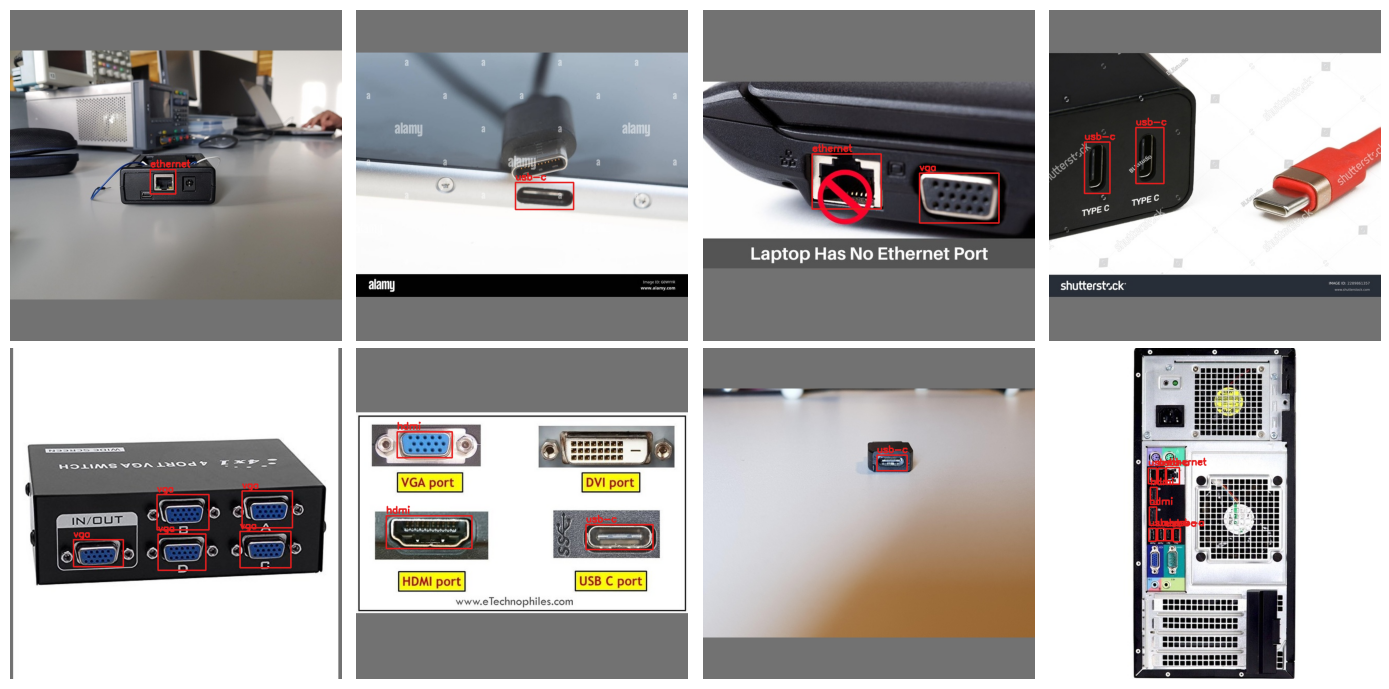

In [8]:
def draw_boxes(image_path, label_path):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    for line in Path(label_path).read_text().splitlines():
        c, xc, yc, bw, bh = line.split()
        xc, yc, bw, bh = float(xc) * w, float(yc) * h, float(bw) * w, float(bh) * h
        x1, y1 = int(xc - bw / 2), int(yc - bh / 2)
        x2, y2 = int(xc + bw / 2), int(yc + bh / 2)
        cv2.rectangle(img, (x1, y1), (x2, y2), (230, 30, 30), 2)
        cv2.putText(img, CLASSES[int(c)], (x1, max(y1 - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (230, 30, 30), 2)
    return img


rng = np.random.default_rng(SEED)
samples = rng.choice(sorted((DATASET / "images" / "train").iterdir()), 8, replace=False)
plt.figure(figsize=(14, 7))
for i, p in enumerate(samples):
    plt.subplot(2, 4, i + 1)
    plt.imshow(draw_boxes(p, DATASET / "labels" / "train" / f"{p.stem}.txt"))
    plt.axis("off")
plt.tight_layout()
plt.show()

# 2. Model and Training Setup

**YOLOv8s** is a single-stage, anchor-free detector with three parts:

| Part | Role |
|:--|:--|
| Backbone | CSP-style CNN that extracts features at several resolutions |
| Neck | Feature pyramid with a spatial pyramid pooling (SPPF) block that mixes coarse and fine features |
| Head | Predicts a box and six class scores at three scales (strides 8, 16, 32) |

The input is an RGB image resized to $640\times640$. The output is a set of boxes with a confidence score and a class,
filtered by non-maximum suppression. We start from COCO-pretrained weights and fine-tune **all** layers (transfer learning).

### Loss

$$
\mathcal{L}=\lambda_{\text{box}}\,\mathcal{L}_{\text{CIoU}}+\lambda_{\text{cls}}\,\mathcal{L}_{\text{BCE}}+\lambda_{\text{dfl}}\,\mathcal{L}_{\text{DFL}},
\qquad (\lambda_{\text{box}},\lambda_{\text{cls}},\lambda_{\text{dfl}})=(7.5,\,0.5,\,1.5),
$$

where $\mathcal{L}_{\text{BCE}}$ is binary cross-entropy on the class scores, and Complete-IoU and
Distribution Focal Loss measure the box error.

### Optimizer

SGD with momentum $\mu=0.937$, learning rate $\eta=0.01$, and weight decay $\lambda=5\times10^{-4}$:

$$
v_{t+1}=\mu v_t+\nabla_\theta\mathcal{L}(\theta_t)+\lambda\theta_t,\qquad
\theta_{t+1}=\theta_t-\eta\,v_{t+1}.
$$

Training uses a 3-epoch warmup, batch size 16, up to 100 epochs, and early stopping after 20 epochs without improvement.
Ultralytics measures improvement with validation mAP@0.5:0.95.

### Regularization

Weight decay, batch normalization, early stopping, and the data augmentations below.

In [9]:
display(pd.DataFrame({"value": AUGMENT}).rename_axis("augmentation"))
print(f"epochs={EPOCHS}, imgsz={IMGSZ}, batch={BATCH}, fraction of training data={FRACTION}")

,value
augmentation,
mosaic,1.000
scale,0.500
translate,0.100
hsv_h,0.015
hsv_s,0.700
hsv_v,0.400
fliplr,0.500


epochs=100, imgsz=640, batch=16, fraction of training data=1.0


# 3. Train the Baseline (with Augmentation)

Weights, learning curves, and logs are saved to `runs/baseline/`. The best checkpoint (highest validation fitness)
is used for all later evaluation.

**If Colab disconnects during training:** finished runs are already saved on Drive.

1. Re-run the cells in **Setup and Imports**.
2. In a new cell, resume the interrupted run from its last checkpoint and set the weight paths:

```python
from ultralytics import YOLO
YOLO("runs/baseline/weights/last.pt").train(resume=True)   # use no_aug instead if that run was interrupted
baseline_weights = RUNS / "baseline" / "weights" / "best.pt"
no_aug_weights = RUNS / "no_aug" / "weights" / "best.pt"
```

3. Continue with the remaining cells, but skip training cells whose run is already finished
   (running them again starts that training from scratch).

In [10]:
baseline_weights = train(f"{PREFIX}baseline", epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, fraction=FRACTION)
assert baseline_weights.exists()
print("Best weights:", baseline_weights)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=None, opset=None, optimize=False, optimi

## Learning Curves

If the validation loss rises while the training loss keeps falling, the model is overfitting.

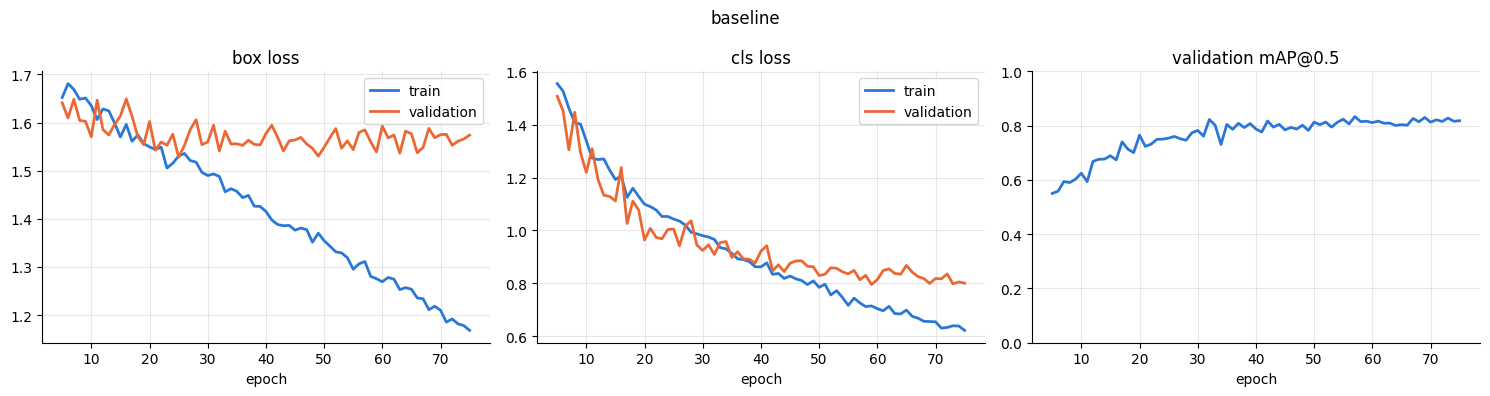

In [11]:
def plot_learning_curves(run_name):
    df = pd.read_csv(RUNS / run_name / "results.csv")
    df.columns = df.columns.str.strip()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, loss in zip(axes[:2], ["box_loss", "cls_loss"]):
        ax.plot(df["epoch"], df[f"train/{loss}"], color="#2a78d6", label="train")
        ax.plot(df["epoch"], df[f"val/{loss}"], color="#eb6834", label="validation")
        ax.set_title(loss.replace("_", " "))
        ax.set_xlabel("epoch")
        ax.legend()
    axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], color="#2a78d6")
    axes[2].set_title("validation mAP@0.5")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylim(0, 1)
    fig.suptitle(run_name)
    plt.tight_layout()
    plt.show()


plot_learning_curves(f"{PREFIX}baseline")

# 4. Augmentation Ablation

Same model and hyperparameters, but every augmentation in Section 2 is set to 0.
Comparing the two models on the test set (Section 5) and on corrupted images (Section 6) shows what augmentation buys.

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=no_aug, nbs=64, nms=None, opset=None, optimize=False, optimizer=

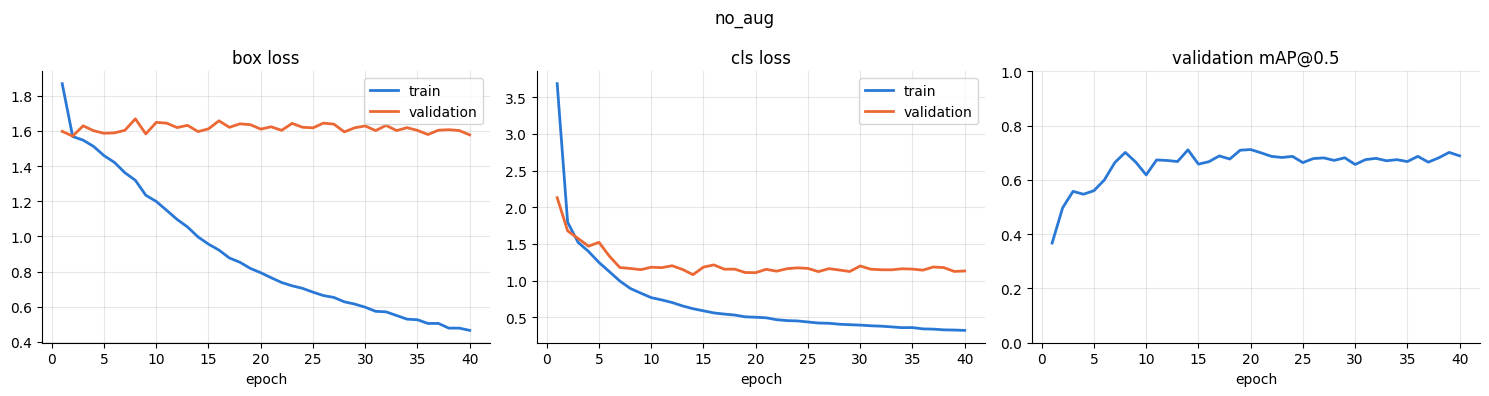

In [12]:
no_aug_weights = train(f"{PREFIX}no_aug", epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
                       fraction=FRACTION, augment=False)
assert no_aug_weights.exists()
plot_learning_curves(f"{PREFIX}no_aug")

### Optional: Input Resolution 960

Ports are small objects, so a larger input may help. Set `RUN_IMG960 = True` to run this (batch 8 to fit T4 memory).

In [13]:
MODELS = {"baseline": (baseline_weights, IMGSZ), "no_aug": (no_aug_weights, IMGSZ)}

if RUN_IMG960:
    img960_weights = train(f"{PREFIX}img960", epochs=EPOCHS, imgsz=960, batch=8, fraction=FRACTION)
    plot_learning_curves(f"{PREFIX}img960")
    MODELS["img960"] = (img960_weights, 960)

# 5. Test-Set Evaluation (RQ1)

A prediction is a **true positive** if its class is correct and it overlaps a ground-truth box with

$$
\operatorname{IoU}(B_{\text{pred}},B_{\text{gt}})=\frac{|B_{\text{pred}}\cap B_{\text{gt}}|}{|B_{\text{pred}}\cup B_{\text{gt}}|}\ge 0.5 .
$$

For each class,

$$
P=\frac{TP}{TP+FP},\qquad R=\frac{TP}{TP+FN},\qquad F_1=\frac{2PR}{P+R},\qquad
\text{AP@0.5}=\int_0^1 P(R)\,dR,
$$

and $\text{mAP@0.5}$ is the mean AP over the six classes.

**Success criteria:** test mAP@0.5 $\ge 0.85$ and every class AP@0.5 $\ge 0.70$.
The test set is used only here, after all training choices are fixed.

In [14]:
test_map, per_class = {}, {}
for name, (weights, size) in MODELS.items():
    map50, rows = evaluate(weights, split="test", imgsz=size, name=f"eval_{PREFIX}{name}_test")
    table = pd.DataFrame(rows).set_index("class")
    table.to_csv(RUNS / f"eval_{PREFIX}{name}_test" / "per_class.csv")
    test_map[name], per_class[name] = map50, table

    success = map50 >= 0.85 and (table["ap50"] >= 0.70).all()
    print(f"\n{name}: mAP@0.5 = {map50:.3f}  ->  success criteria {'MET' if success else 'NOT met'}")
    display(table)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.5±16.2 MB/s, size: 63.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/project/prepared/labels/test... 171 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 379.0it/s 0.5s
val: New cache created: /content/project/prepared/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.5it/s 4.5s
                   all        171        507      0.712      0.739      0.744      0.413
Speed: 3.7ms preprocess, 11.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/drive/MyDrive/CS4343-port-detection/runs/eval_baseline_test

baseline: 

,precision,recall,f1,ap50
class,,,,
displayport,0.4877,0.4062,0.4433,0.4032
ethernet,0.8725,0.8200,0.8454,0.8874
hdmi,0.5744,0.7368,0.6455,0.7060
usb-a,0.8231,0.8940,0.8571,0.8854
usb-c,0.7224,0.7808,0.7505,0.7648
vga,0.7931,0.7959,0.7945,0.8190


Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1298.4±558.6 MB/s, size: 51.1 KB)
val: Scanning /content/project/prepared/labels/test.cache... 171 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 42.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.5it/s 4.3s
                   all        171        507      0.746       0.61      0.665      0.373
Speed: 2.5ms preprocess, 11.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/drive/MyDrive/CS4343-port-detection/runs/eval_no_aug_test

no_aug: mAP@0.5 = 0.665  ->  success criteria NOT met


,precision,recall,f1,ap50
class,,,,
displayport,0.4314,0.2812,0.3405,0.3095
ethernet,0.9169,0.6600,0.7675,0.7321
hdmi,0.7225,0.5614,0.6318,0.6572
usb-a,0.7993,0.7948,0.7970,0.8022
usb-c,0.7748,0.6556,0.7102,0.6923
vga,0.8320,0.7074,0.7646,0.7974


## Per-Class AP@0.5

The dashed line is the per-class target of 0.70.

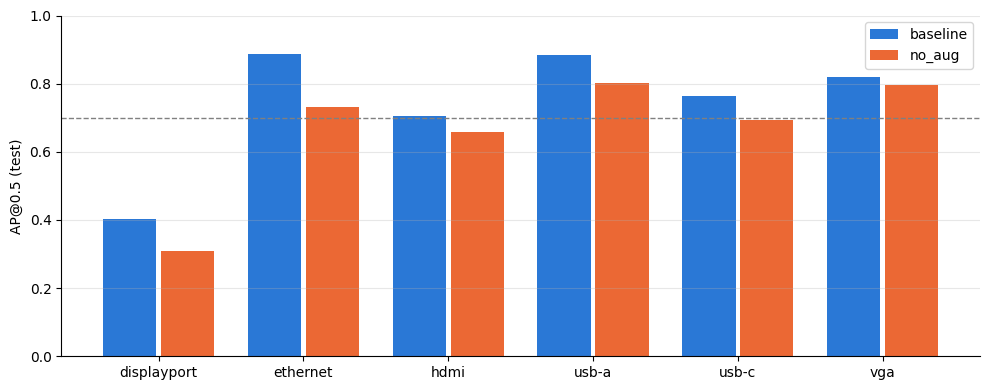

In [15]:
ap = pd.DataFrame({name: t["ap50"] for name, t in per_class.items()}).reindex(CLASSES)
x = np.arange(len(CLASSES))
width = 0.8 / len(ap.columns)

fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(ap.columns):
    ax.bar(x + i * width - 0.4 + width / 2, ap[name], width * 0.92, color=COLORS[name], label=name)
ax.axhline(0.70, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x, CLASSES)
ax.set_ylim(0, 1)
ax.set_ylabel("AP@0.5 (test)")
ax.legend()
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## Confusion Matrix (Baseline)

Rows are predicted classes and columns are true classes. The extra **background** row and column count
missed ports (false negatives) and detections where there is no port (false positives).

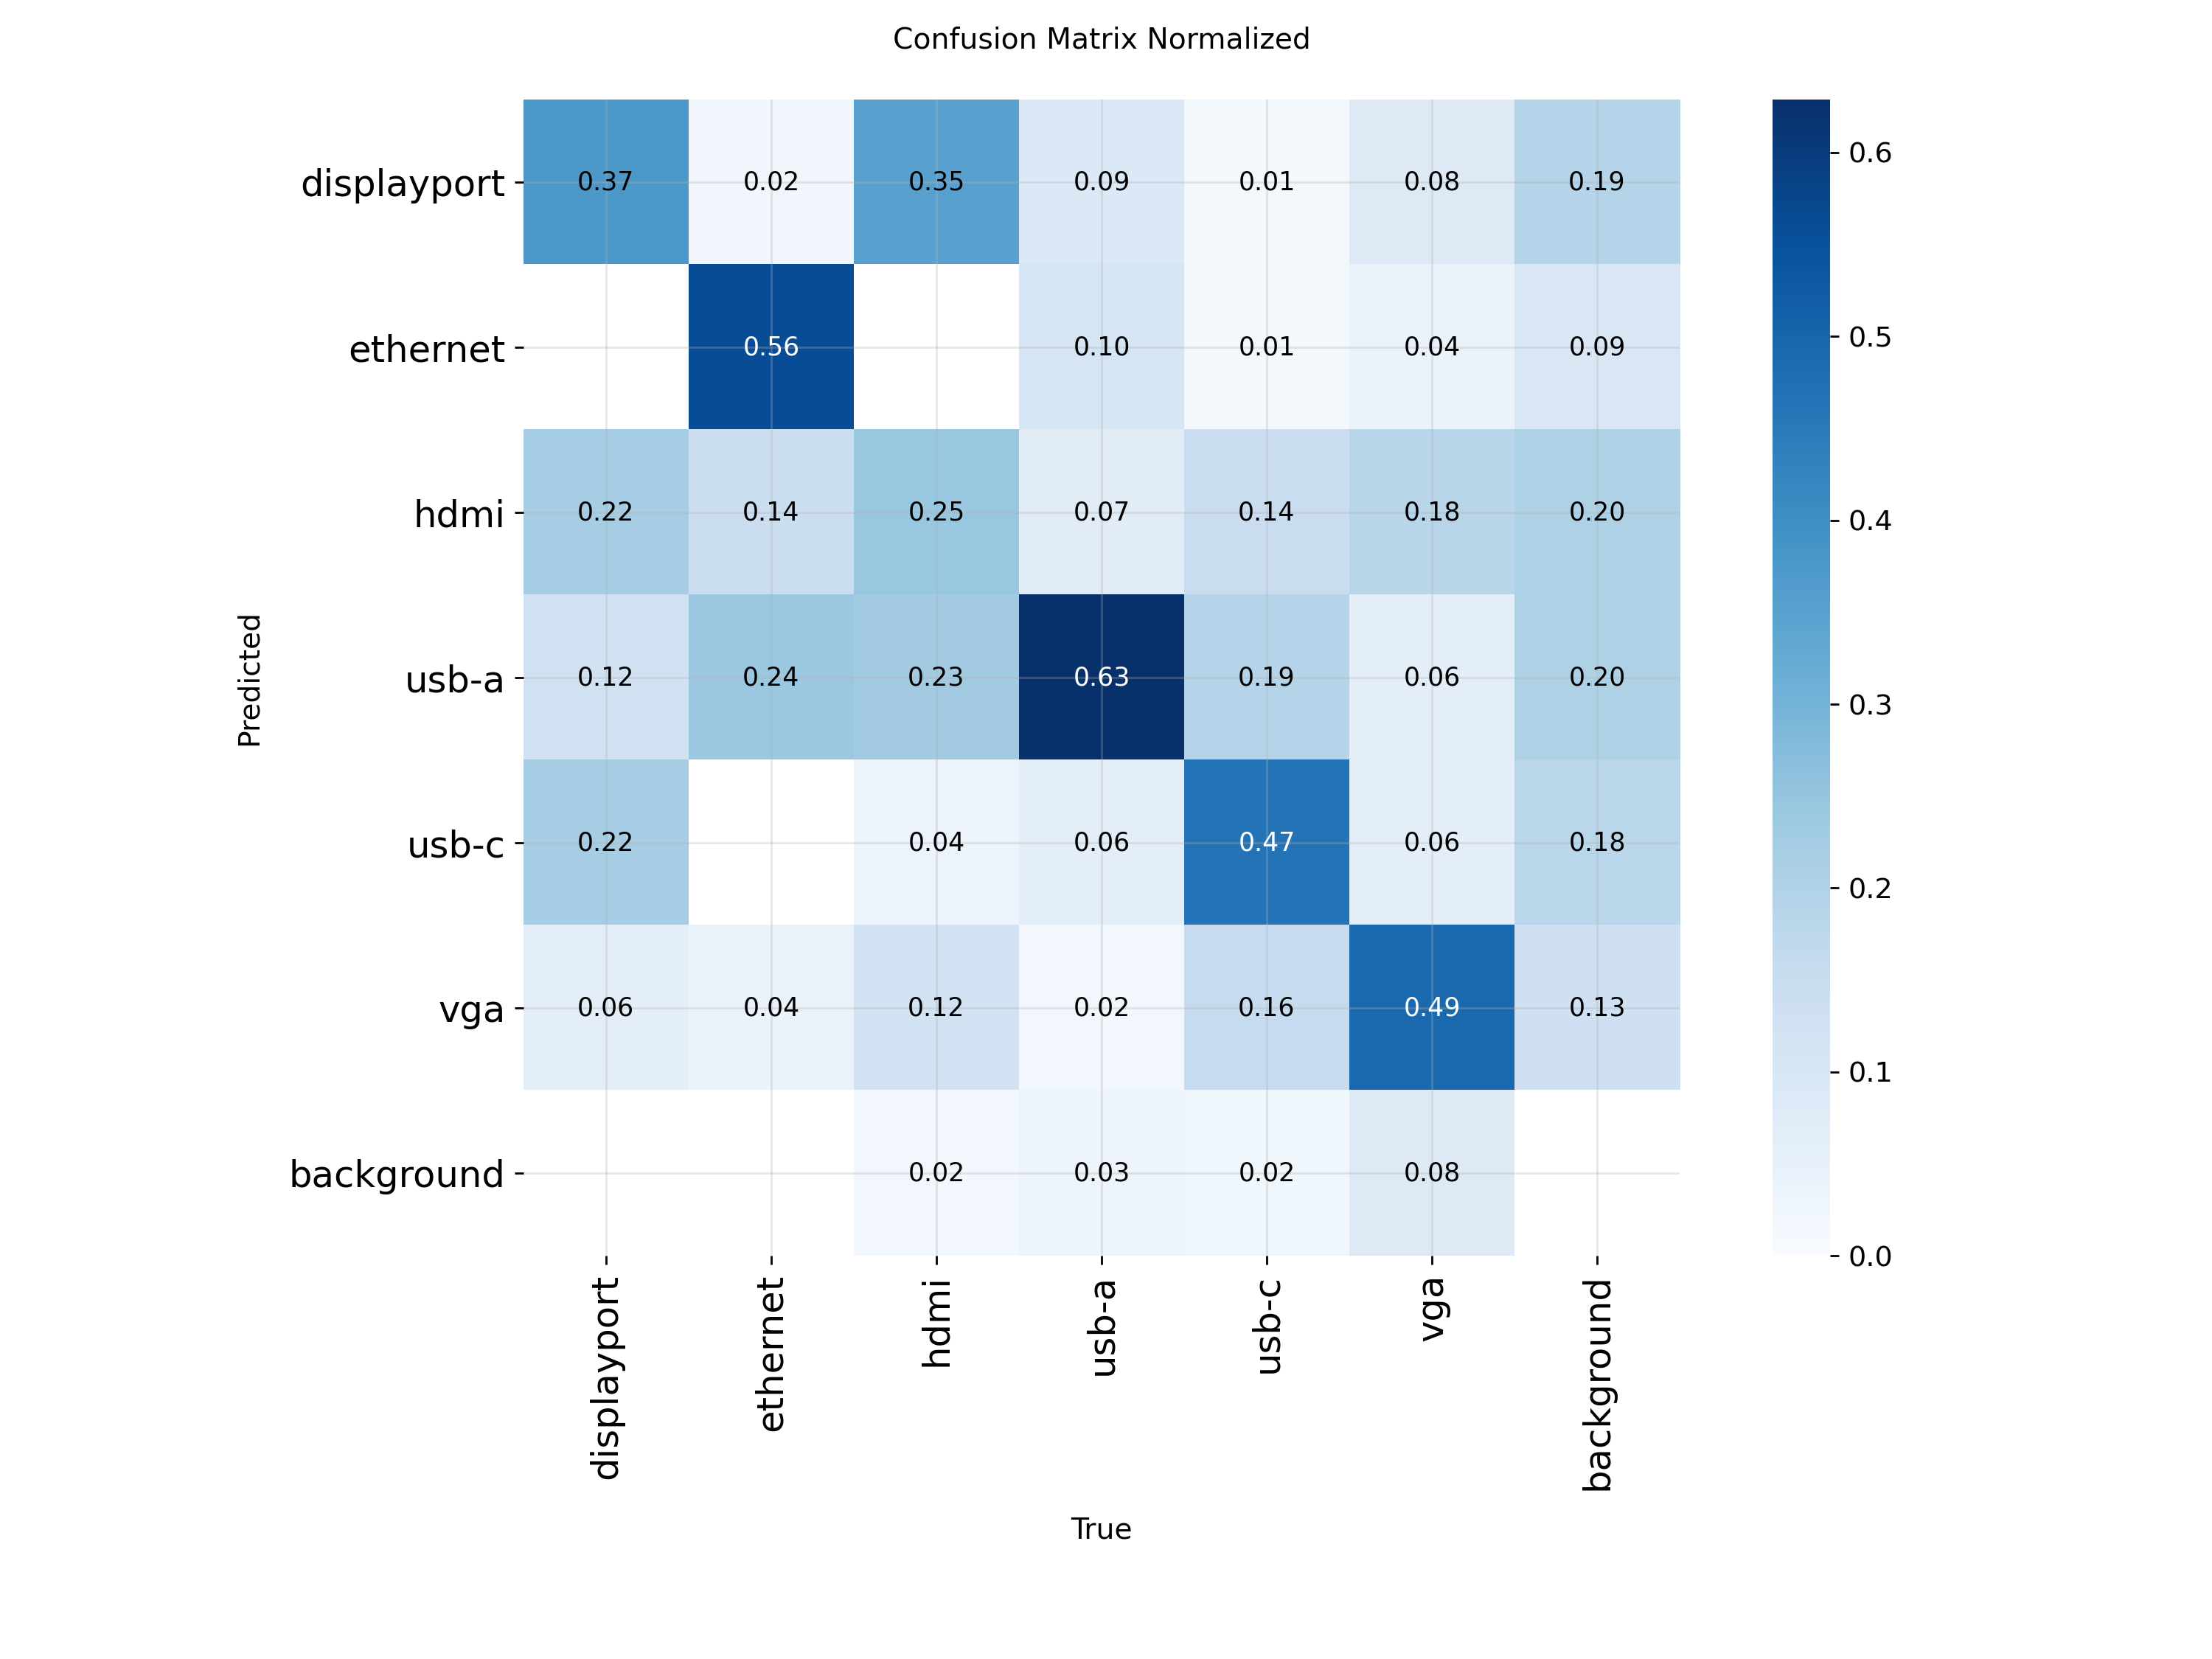

In [16]:
display(Image(str(RUNS / f"eval_{PREFIX}baseline_test" / "confusion_matrix_normalized.png"), width=650))

# 6. Robustness to Image Corruptions (RQ2)

Each corruption is applied to every test image at three severity levels:

| Corruption | Severity 1 | Severity 2 | Severity 3 |
|:--|:--|:--|:--|
| Gaussian noise (std, pixel values 0–255) | 10 | 25 | 50 |
| Motion blur (kernel length, px) | 5 | 11 | 21 |
| JPEG compression (quality) | 30 | 15 | 5 |
| Brightness (multiplier) | 0.7 | 0.5 | 0.3 |

The labels stay the same, so any drop in mAP@0.5 is caused by the corruption alone.

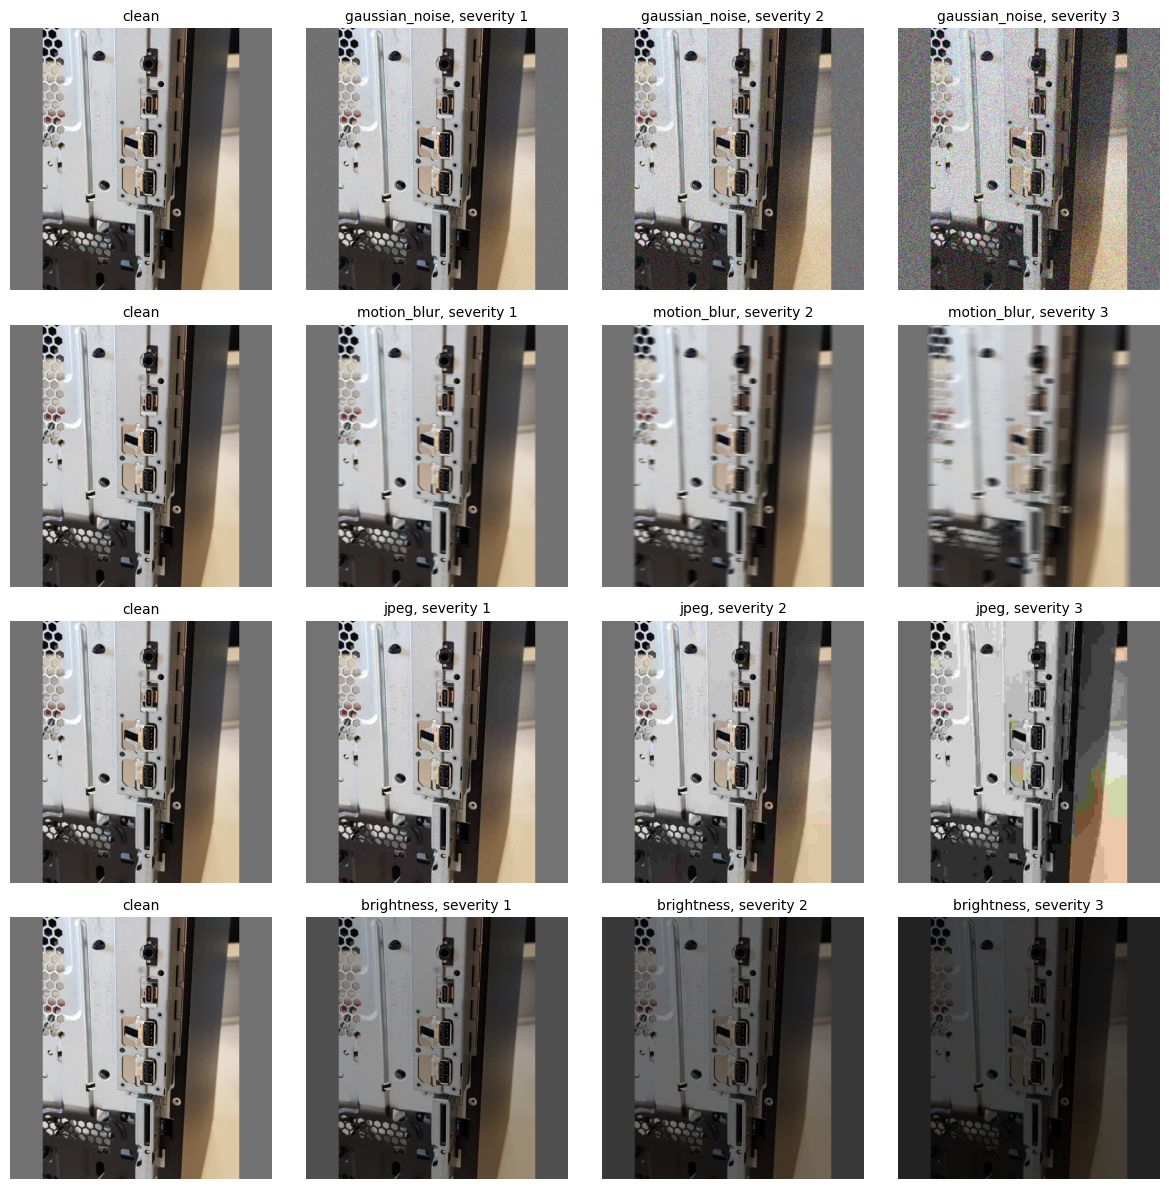

In [17]:
example = sorted((DATASET / "images" / "test").iterdir())[0]
img = cv2.imread(str(example))

fig, axes = plt.subplots(len(SEVERITY), 4, figsize=(12, 3 * len(SEVERITY)))
for r, kind in enumerate(SEVERITY):
    for level in range(4):
        out = img if level == 0 else corrupt(img, kind, level)
        axes[r, level].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        axes[r, level].set_title(f"{kind}, severity {level}" if level else "clean", fontsize=10)
        axes[r, level].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
KINDS = ["jpeg"] if QUICK_TEST else list(SEVERITY)  # one corruption is enough for a quick check

robust = {}
for name in ["baseline", "no_aug"]:
    weights, size = MODELS[name]
    robust[name] = pd.DataFrame(run_robustness(weights, imgsz=size, kinds=KINDS))
    print(name)
    display(robust[name])

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1316.3±685.6 MB/s, size: 79.7 KB)
val: Scanning /content/project/prepared/labels/test.cache... 171 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 35.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.2it/s 3.4s
                   all        171        507      0.712      0.739      0.744      0.413
Speed: 1.6ms preprocess, 11.5ms inference, 0.0ms loss, 1.9ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2768.5±1131.0 MB/s, size: 194.7 KB)
val: Scanning /content/project/corrupted/gaussian_noise_1/l

## mAP@0.5 vs. Severity

Severity 0 is the clean test set. A flatter line means a more robust model.

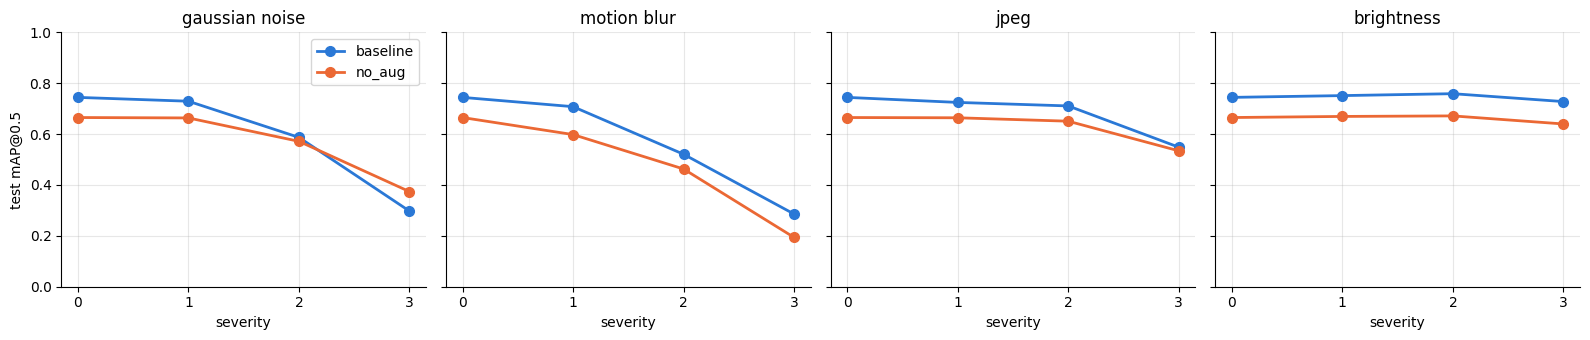

In [24]:
fig, axes = plt.subplots(1, len(KINDS), figsize=(4 * len(KINDS), 3.5), sharey=True, squeeze=False)
for ax, kind in zip(axes[0], KINDS):
    for name, df in robust.items():
        clean = df[df["corruption"] == "clean"]
        rows = pd.concat([clean, df[df["corruption"] == kind]])
        ax.plot(rows["severity"], rows["map50"], marker="o", markersize=7, color=COLORS[name], label=name)
    ax.set_title(kind.replace("_", " "))
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xlabel("severity")
    ax.set_ylim(0, 1)
axes[0, 0].set_ylabel("test mAP@0.5")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

# 7. Failure Cases

Ultralytics saves the ground truth (left) and the baseline predictions (right) for the first test batch.
Look for missed small ports, confusions between similar shapes (e.g. HDMI vs. DisplayPort, USB-A vs. Ethernet),
and false detections on background objects.

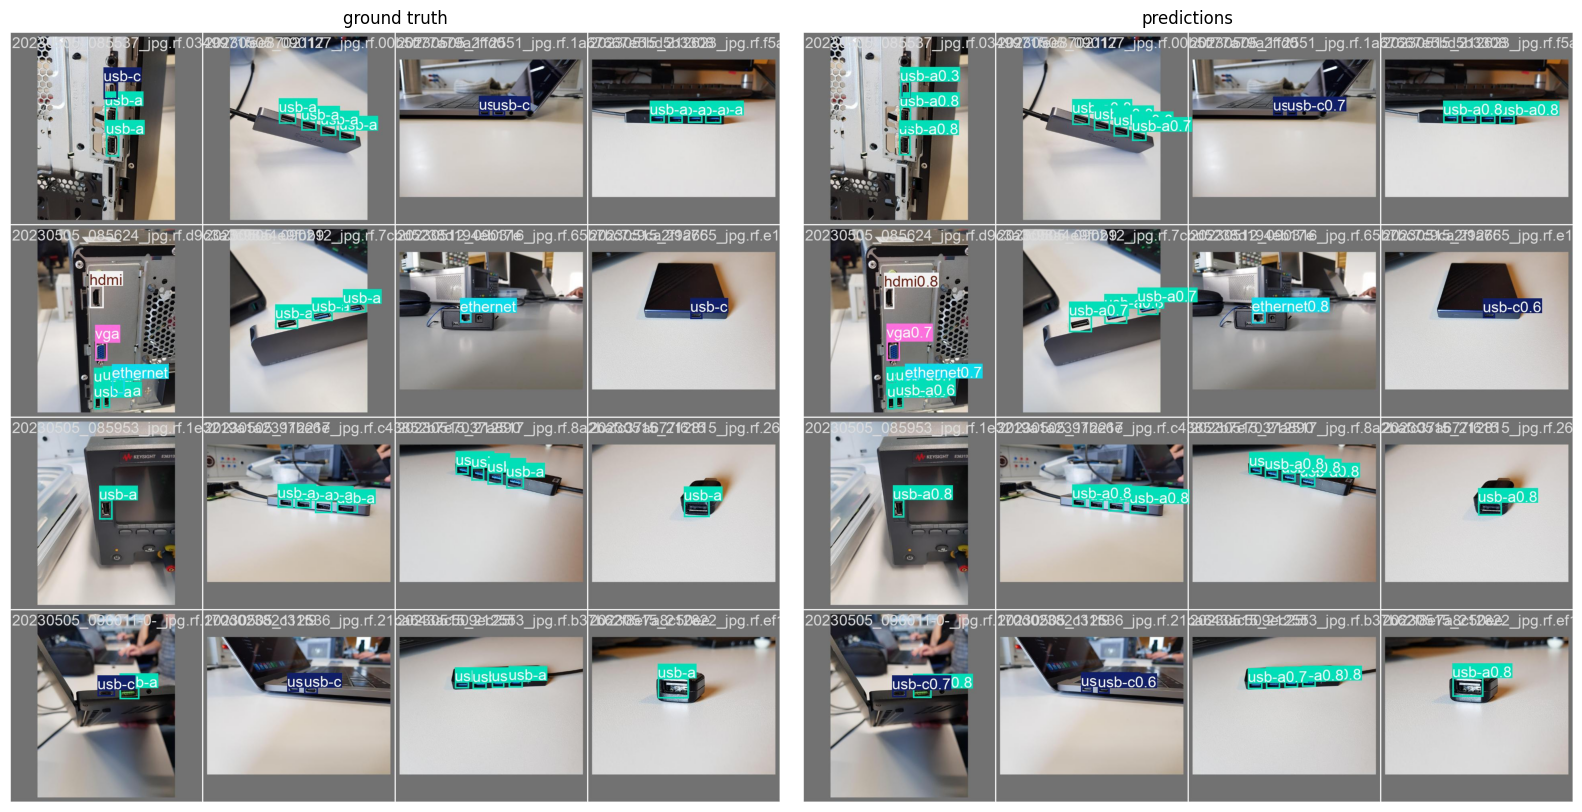

In [23]:
eval_dir = RUNS / f"eval_{PREFIX}baseline_test"
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (title, file) in zip(axes, [("ground truth", "val_batch0_labels.jpg"),
                                    ("predictions", "val_batch0_pred.jpg")]):
    ax.imshow(plt.imread(eval_dir / file))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 8. Summary

In [22]:
base = per_class["baseline"]
print(f"Baseline test mAP@0.5: {test_map['baseline']:.3f}   (no augmentation: {test_map['no_aug']:.3f})")
print(f"Hardest class: {base['ap50'].idxmin()} (AP@0.5 = {base['ap50'].min():.3f}, "
      f"recall = {base.loc[base['ap50'].idxmin(), 'recall']:.3f})")

drops = {}
for name, df in robust.items():
    clean = df.loc[df["corruption"] == "clean", "map50"].item()
    drops[name] = (clean - df[df["severity"] == 3].set_index("corruption")["map50"]).round(3)
print("\nmAP@0.5 drop from clean to severity 3 (smaller is more robust):")
display(pd.DataFrame(drops))

Baseline test mAP@0.5: 0.744   (no augmentation: 0.665)
Hardest class: displayport (AP@0.5 = 0.403, recall = 0.406)

mAP@0.5 drop from clean to severity 3 (smaller is more robust):


,baseline,no_aug
corruption,,
gaussian_noise,0.447,0.291
motion_blur,0.459,0.471
jpeg,0.196,0.131
brightness,0.016,0.025
